# ML Lab 4

**Experiment 1:** Consider a dataset ‘sales’ based on 'TV' marketing budget. Build a linear
regression model to predict 'Sales' using 'TV' as the predictor variable.
Dataset Link : https://github.com/Yashappin/Machine-Learning/blob/master/TvMarketing.csv

a) Importing data and understanding its structure.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving TvMarketing.csv to TvMarketing.csv


In [ ]:
import pandas as pd

df = pd.read_csv("TvMarketing.csv")

# first 5 rows
print(df.head())

      TV  Sales
0  230.1   22.1
1   44.5   10.4
2   17.2    9.3
3  151.5   18.5
4  180.8   12.9


In [ ]:
# structure
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Sales   200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB
None


In [ ]:
# stats summary
print(df.describe())

               TV       Sales
count  200.000000  200.000000
mean   147.042500   14.022500
std     85.854236    5.217457
min      0.700000    1.600000
25%     74.375000   10.375000
50%    149.750000   12.900000
75%    218.825000   17.400000
max    296.400000   27.000000


b) Visualising Data Using Plot.

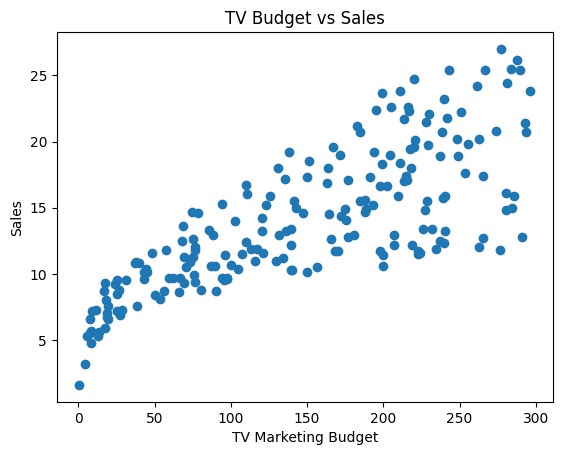

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df["TV"], df["Sales"])
plt.xlabel("TV Marketing Budget")
plt.ylabel("Sales")
plt.title("TV Budget vs Sales")
plt.show()


c) Splitting Data into Training and Testing Sets (80:20). Also display the shape of Training and
testing data shape.

In [ ]:
from sklearn.model_selection import train_test_split

X = df[["TV"]]     # predictor
y = df["Sales"]    # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (160, 1)
X_test shape: (40, 1)
y_train shape: (160,)
y_test shape: (40,)


d) Train a Simple Linear regression Model (𝒚 = 𝒃𝟎 + 𝒃𝟏 × 𝑿) and calculate the value of
optimal model parameters, thereafter, visualised the best fit line.

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# optimal parameters
b0 = model.intercept_
b1 = model.coef_[0]

print("Intercept (b0):", b0)
print("Slope (b1):", b1)
print("Model equation: Sales =", b0, "+", b1, "* TV")

Intercept (b0): 7.119638430592953
Slope (b1): 0.046529733705443346
Model equation: Sales = 7.119638430592953 + 0.046529733705443346 * TV


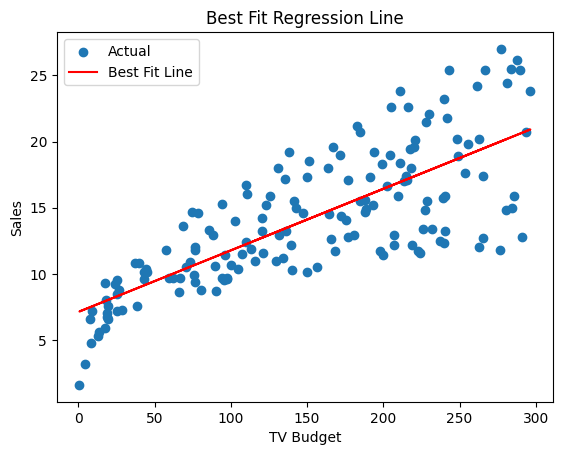

In [ ]:
# predictions on training data
y_train_pred = model.predict(X_train)

plt.scatter(X_train, y_train, label="Actual")
plt.plot(X_train, y_train_pred, color="red", label="Best Fit Line")
plt.xlabel("TV Budget")
plt.ylabel("Sales")
plt.title("Best Fit Regression Line")
plt.legend()
plt.show()

e) Display actual vs predicted sales.

In [ ]:
# predictions on test data
y_pred = model.predict(X_test)

result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(result.head(10))

   Actual  Predicted
0    16.9  14.717944
1    22.4  16.211548
2    21.4  20.748197
3     7.3   7.664036
4    24.7  17.370139
5    12.6  10.614021
6    22.3  17.207285
7     8.4   9.446125
8    11.5  17.467851
9    14.9  15.266995


f) Computing RMSE and 𝑅^2 Values

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 3.194472431998898
R² Score: 0.6766954295627076


**Experiment-2:** Multiple regression is a statistical method used to model the relationship
between multiple independent variables and a dependent variable. Perform multiple linear
regression using the following dataset.

Dataset Link : https://www.kaggle.com/datasets/midhundasl/co2-emission-of-cars-dataset


Description: This dataset contains the co2 emission of different types of cars. The independent feature
variables are VOLUME and WEIGHT. By Using Multiple Linear regression models we can predict the
amount of CO2 emitted by cars per unit volume and weight.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving DATA.csv to DATA.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv("DATA.csv")

print("First 5 rows:\n", df.head())
print("\nDataset Info:\n")
print(df.info())
print("\nStatistical Summary:\n", df.describe())

First 5 rows:
           Car       Model  Volume  Weight  CO2  Unnamed: 5
0      Toyota        Aygo    1000     790   99         NaN
1  Mitsubishi  Space Star    1200    1160   95         NaN
2       Skoda      Citigo    1000     929   95         NaN
3        Fiat         500     900     865   90         NaN
4        Mini      Cooper    1500    1140  105         NaN

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Car         36 non-null     object 
 1   Model       36 non-null     object 
 2   Volume      36 non-null     int64  
 3   Weight      36 non-null     int64  
 4   CO2         36 non-null     int64  
 5   Unnamed: 5  0 non-null      float64
dtypes: float64(1), int64(3), object(2)
memory usage: 1.8+ KB
None

Statistical Summary:
             Volume       Weight         CO2  Unnamed: 5
count    36.000000    36.000000   36.00


Correlation Matrix:
           Volume    Weight       CO2
Volume  1.000000  0.753537  0.592082
Weight  0.753537  1.000000  0.552150
CO2     0.592082  0.552150  1.000000


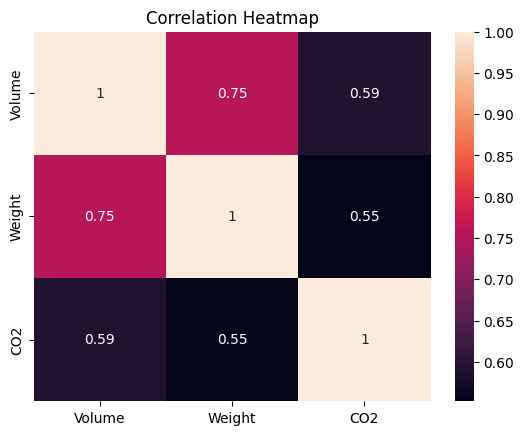

In [ ]:
corr = df[['Volume','Weight','CO2']].corr()
print("\nCorrelation Matrix:\n", corr)

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

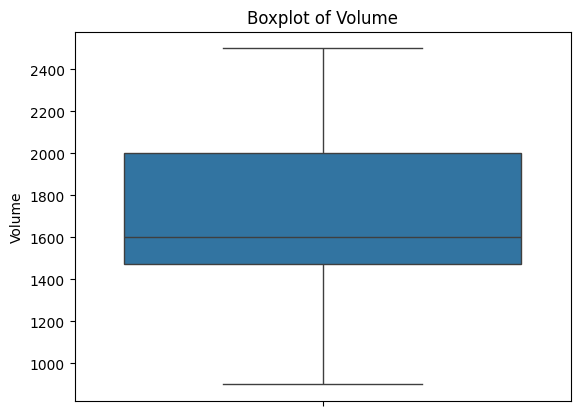

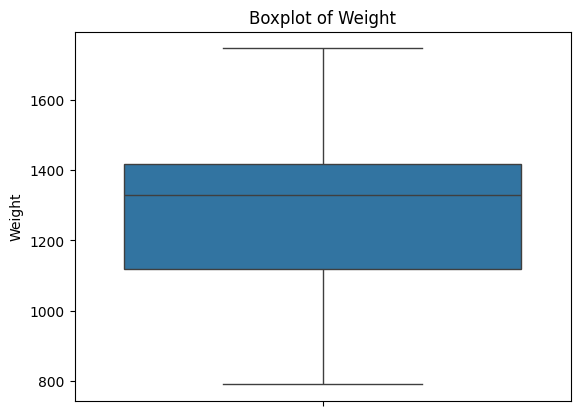

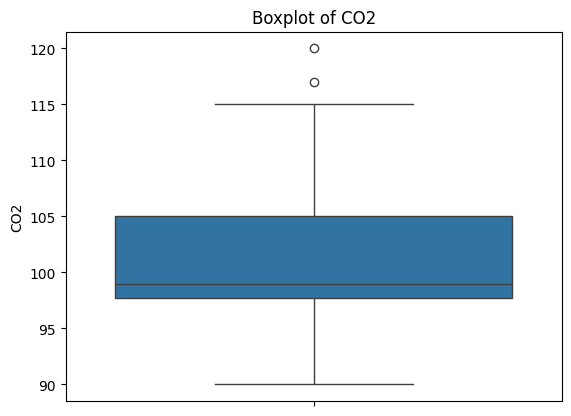

In [ ]:
features = ['Volume','Weight','CO2']

for col in features:
    plt.figure()
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

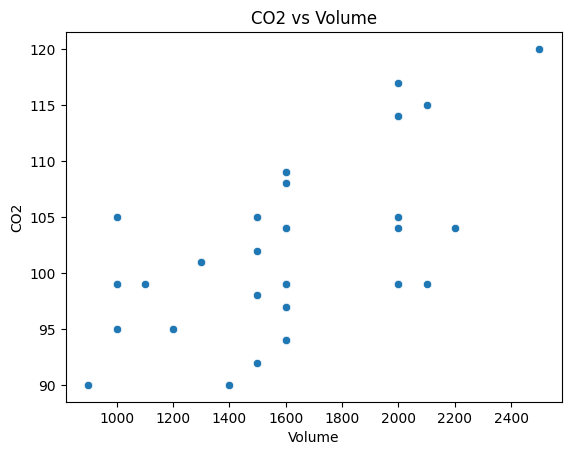

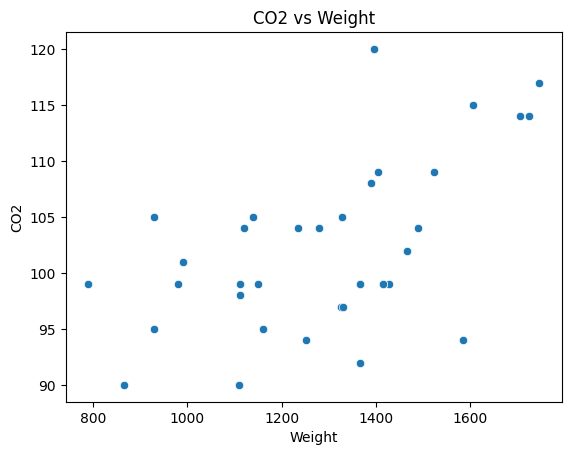

In [ ]:
plt.figure()
sns.scatterplot(x=df['Volume'], y=df['CO2'])
plt.title("CO2 vs Volume")
plt.show()

plt.figure()
sns.scatterplot(x=df['Weight'], y=df['CO2'])
plt.title("CO2 vs Weight")
plt.show()

In [ ]:
X = df[['Volume','Weight']]
y = df['CO2']

# 80:20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model training
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()


Regression Coefficients:
Volume coefficient: 0.004287414249075688
Weight coefficient: 0.008049279585677119
Intercept: 84.21502006695282


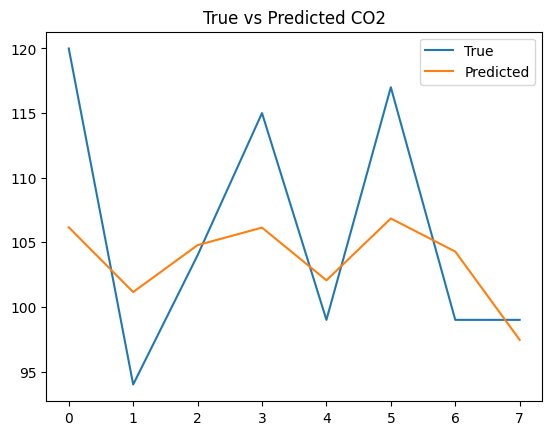

In [ ]:
print("\nRegression Coefficients:")
print("Volume coefficient:", model.coef_[0])
print("Weight coefficient:", model.coef_[1])
print("Intercept:", model.intercept_)

# Predictions
y_pred = model.predict(X_test)

# True vs Predicted line plot
plt.figure()
plt.plot(y_test.values, label="True")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("True vs Predicted CO2")
plt.show()

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\nModel Evaluation Metrics:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)


Model Evaluation Metrics:
MAE: 6.335639624274503
MSE: 58.07928583657771
RMSE: 7.620976698335832


**Experiment-3:** Given below the link of a dataset to predict whether a user will click on an online a based on their demographics, browsing behaviour, the context of the ad's display, and the time of day using Logistic regression.
[Logistic Regression : Logistic Regression is commonly used to estimate the probability that an instance belongs to a particular class. If the estimated probability that an instance is greater than 50%, then the model predicts that the instance belongs to that class 1, or else it predicts that it does not. This makes it a binary classifier.]


Dataset Link : https://www.kaggle.com/datasets/gabrielsantello/advertisement-click-on-ad
This dataset provides insights into user behaviour and online advertising, specifically focusing on predicting whether a user will click on an online advertisement. It contains user demographic information, browsing habits, and details related to the display of the advertisement. This dataset is ideal for building binary classification models to predict user interactions with online ads.
a)	Load and display the information about the dataset.
b)	Apply Exploratory data analysis of the dataset (Missing value treatment. Null value treatment, Data transformation and normalization)
c)	Find co-relation among the features and display the heatmap.
d)	Train a logistic regression model and calculate the model parameters. (Train-Test Split should be 80:20).
e)	Also apply K-fold cross validation split and record all the results.
f)	Display the classification report like (Precision, recall and F1-score).
g)	Display the confusion matrix and ROC curve, Precision Recall curve.
h)	Visualised the predicted vs actual outcome.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving advertising.csv to advertising.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve
)

df = pd.read_csv("advertising.csv")

print("\nDataset Head:\n", df.head())
print("\nDataset Info:")
print(df.info())
print("\nStatistical Summary:\n", df.describe())


Dataset Head:
    Daily Time Spent on Site  Age  Area Income  Daily Internet Usage  \
0                     68.95   35     61833.90                256.09   
1                     80.23   31     68441.85                193.77   
2                     69.47   26     59785.94                236.50   
3                     74.15   29     54806.18                245.89   
4                     68.37   35     73889.99                225.58   

                           Ad Topic Line            City  Male     Country  \
0     Cloned 5thgeneration orchestration     Wrightburgh     0     Tunisia   
1     Monitored national standardization       West Jodi     1       Nauru   
2       Organic bottom-line service-desk        Davidton     0  San Marino   
3  Triple-buffered reciprocal time-frame  West Terrifurt     1       Italy   
4          Robust logistical utilization    South Manuel     0     Iceland   

             Timestamp  Clicked on Ad  
0  2016-03-27 00:53:11              0  
1  2016-

In [ ]:
print("\nMissing Values:\n", df.isnull().sum())

drop_cols = ["Ad Topic Line", "City", "Country", "Timestamp"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")

if "Gender" in df.columns:
    df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})

scaler = StandardScaler()

features = df.drop("Clicked on Ad", axis=1)
target = df["Clicked on Ad"]

scaled_features = scaler.fit_transform(features)
X = pd.DataFrame(scaled_features, columns=features.columns)
y = target


Missing Values:
 Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Ad Topic Line               0
City                        0
Male                        0
Country                     0
Timestamp                   0
Clicked on Ad               0
dtype: int64


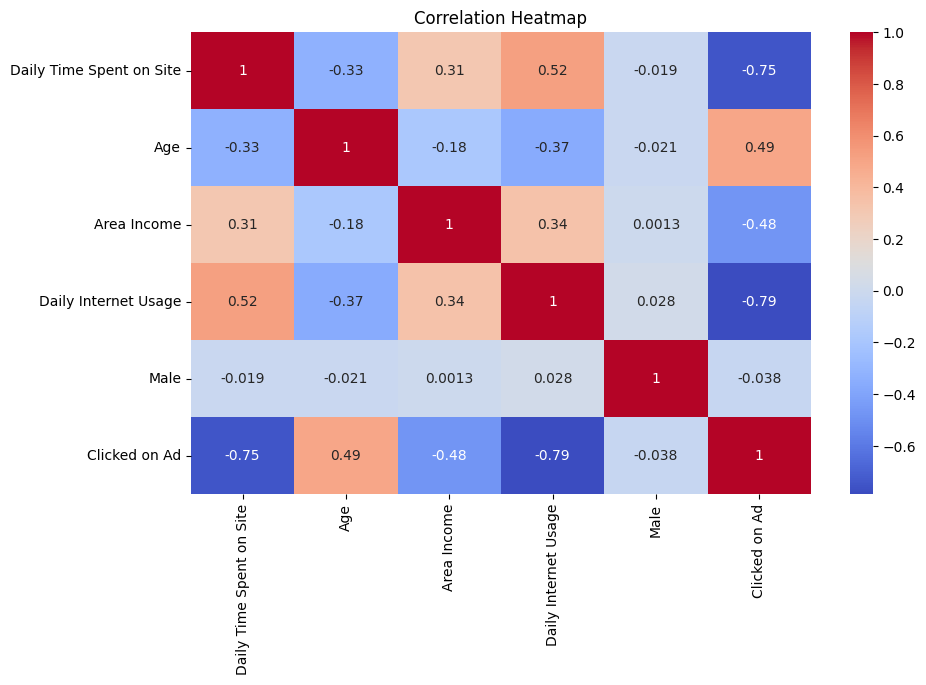

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

print("\nModel Coefficients:")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"{feature}: {coef:.4f}")

print("\nIntercept:", model.intercept_[0])


Model Coefficients:
Daily Time Spent on Site: -2.5255
Age: 1.2506
Area Income: -1.6370
Daily Internet Usage: -2.7040
Male: -0.3586

Intercept: 1.4757124726445308


In [ ]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=kfold)

print("\nK-Fold Accuracy Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())


K-Fold Accuracy Scores: [0.96  0.98  0.985 0.96  0.97 ]
Mean Accuracy: 0.9709999999999999


In [ ]:
y_pred = model.predict(X_test)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.97      0.96        89
           1       0.97      0.95      0.96       111

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



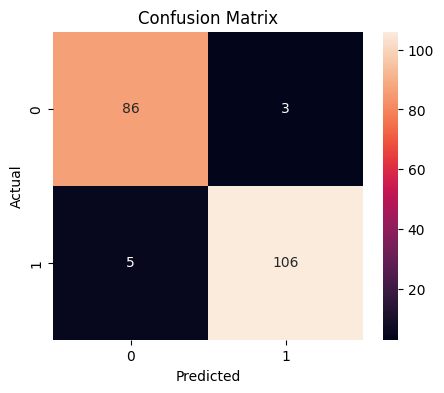

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

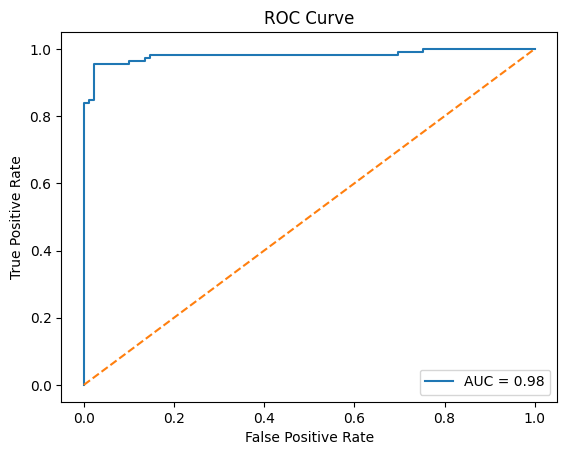

In [ ]:
# ROC Curve
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

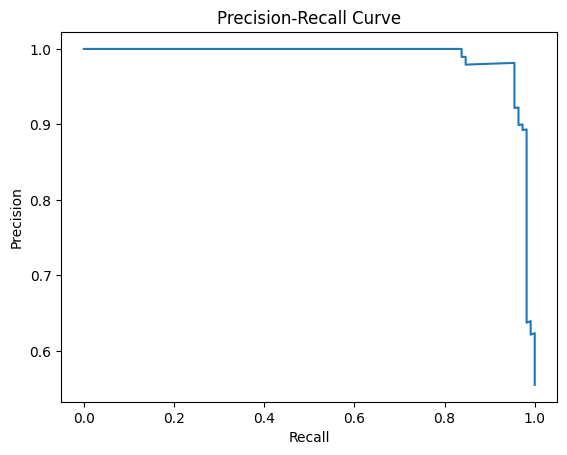

In [ ]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

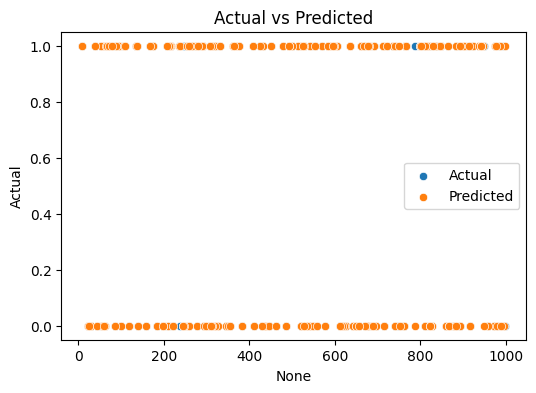

In [ ]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

plt.figure(figsize=(6,4))
sns.scatterplot(x=results.index, y="Actual", data=results, label="Actual")
sns.scatterplot(x=results.index, y="Predicted", data=results, label="Predicted")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()